In [1]:
# making somewhat cleaned-up versions of figures for figure 3 + related supplementary figures; 

In [2]:
import utils # ./utils.py
import os
import re
import math
import random
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
import itertools
from itertools import combinations
import seaborn as sns
import matplotlib 
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib import cm
import matplotlib.font_manager
%matplotlib inline

In [3]:
# pre-processed data:
# excluded samples: SK1_8 (very low coverage), SK1_11 (duplicate of SK1_10), LS01_17 (no spike-in detected), LS01_32 (no reads)
metadata = pd.read_csv('/Users/alyulina/Projects/Cancer/Data/metadata.csv', index_col='sample id') # all sequencing samples
read_counts_by_cell_line = pd.read_csv('/Users/alyulina/Projects/Cancer/Data/cell-line_read_counts.csv', index_col='clID')
cell_counts_by_cell_line = pd.read_csv('/Users/alyulina/Projects/Cancer/Data/cell-line_cell_counts.csv', index_col='clID')

clIDs = utils.clIDs
clID__label = utils.clID__label
clID__color = utils.clID__color 

# where to find data:
path_to_reads = '/Users/alyulina/Projects/Cancer/Data/bc_counts/'

# where to save plots:
path_to_save_figs = '/Users/alyulina/Projects/Cancer/Figures/fig3/'

In [4]:
# note that the figures might change slightly each time you run this code, 
# so make sure to update annotations accordingly

### Immune rejection plots

In [5]:
# making a list of 3w F1 iv lung samples from exp. one
what = ['1', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [6]:
# making a list of 3w Rag1 iv lung samples from exp. one
what = ['1', 20, 'Rag1-/-', 'intravenous', 'lung']
samples_wo_immune_system = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                   (metadata['time point, d'] > what[1]) & # be careful here
                                   (metadata['genotype'] == what[2]) &
                                   (metadata['injection method'] == what[3]) & 
                                   (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [7]:
clID__in_vivo_exp, clID__in_vivo_exp_avg_relative_to_mean, clID__in_vivo_exp_err, clIDs_sorted = utils.bootstrap_relative_burden(samples, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)
clID__in_vivo_exp_wo_immune_system, clID__in_vivo_exp_avg_wo_immune_system_relative_to_mean, clID__in_vivo_exp_wo_immune_system_err, clIDs_sorted_wo_immune_system = utils.bootstrap_relative_burden(samples_wo_immune_system, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)


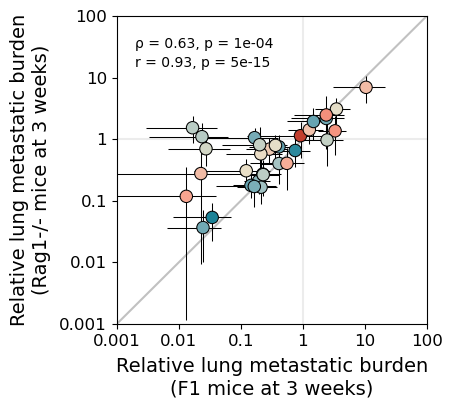

In [8]:
ax = utils.comparison_scatter_plot([x for x in clIDs if x not in ['GATC', 'AGCA']],
                                    clID__x=clID__in_vivo_exp_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_err,
                                    clID__y=clID__in_vivo_exp_avg_wo_immune_system_relative_to_mean, clID__yerr=clID__in_vivo_exp_wo_immune_system_err,
                                    xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative lung metastatic burden\n(Rag1-/- mice at 3 weeks)',
                                    lims=[1e-3, 1e2], ticks=[1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], labels=['0.001', '0.01', '0.1', '1', '10', '100'])

#plt.savefig(path_to_save_figs + 'fig3_relative_in_vivo_exp_w_and_wo_immune_system_exp1.pdf', dpi=300, bbox_inches='tight')  

In [9]:
# calculating immune rejection index
clID__immune_rejection_index_distr = {}
clID__immune_rejection_index_avg_relative_to_mean = {}
clID__immune_rejection_index_err = {}
for clID in clIDs:
    if clID in ['GATC', 'AGCA']:
        continue
    clID__immune_rejection_index_distr[clID] = clID__in_vivo_exp_wo_immune_system[clID] / clID__in_vivo_exp[clID]
    
y_mean = np.mean([np.mean(clID__immune_rejection_index_distr[clID]) for clID in clIDs if clID not in ['GATC', 'AGCA']])

for clID in clIDs:
    if clID in ['GATC', 'AGCA']:
        continue
    y = np.mean(clID__immune_rejection_index_distr[clID])
    
    ci_upper = np.percentile(clID__immune_rejection_index_distr[clID], 97.5)
    ci_lower = np.percentile(clID__immune_rejection_index_distr[clID], 2.5)
    clID__immune_rejection_index_err[clID] = [(y - ci_lower) / y_mean, (ci_upper - y) / y_mean]
    clID__immune_rejection_index_avg_relative_to_mean[clID] = y / y_mean
    
clIDs_sorted = [y[0] for y in sorted([[x, clID__immune_rejection_index_avg_relative_to_mean[x]] for x in clIDs if x not in ['GATC', 'AGCA']], key = lambda x: x[-1], reverse=True)]

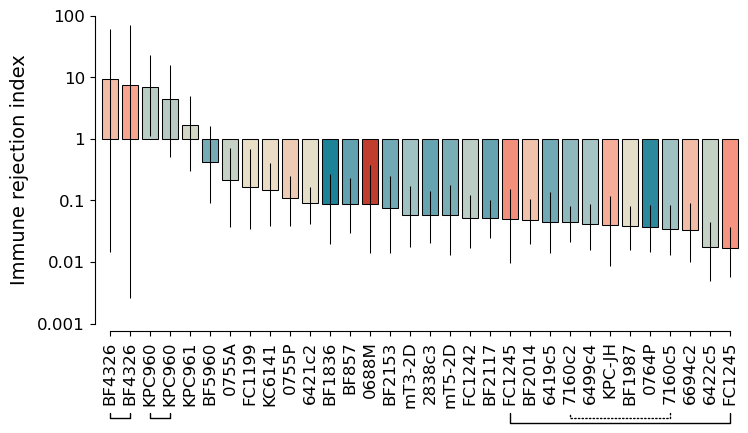

In [10]:
ax = utils.metric_bar_plot(clIDs_sorted, clID__immune_rejection_index_avg_relative_to_mean, clID__immune_rejection_index_err, 
                           ytitle='Immune rejection index', 
                           ylims=[1e-3, 1e2], yticks=[1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], ylabels=['0.001', '0.01', '0.1', '1', '10', '100'])

ax.annotate('', xy=(0, 0.00004), xycoords='data', xytext=(1, 0.00004), textcoords='data',
            arrowprops=dict(arrowstyle='-', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.4'), 
            annotation_clip=False);

ax.annotate('', xy=(2, 0.00004), xycoords='data', xytext=(3, 0.00004), textcoords='data',
            arrowprops=dict(arrowstyle='-', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.4'), 
            annotation_clip=False);

ax.annotate('', xy=(20, 0.00004), xycoords='data', xytext=(31, 0.00004), textcoords='data',
            arrowprops=dict(arrowstyle='-', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.06'), 
            annotation_clip=False);

ax.annotate('', xy=(23, 0.00004), xycoords='data', xytext=(28, 0.00004), textcoords='data',
            arrowprops=dict(arrowstyle='-', linestyle=':', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.08'), 
            annotation_clip=False);

#plt.savefig(path_to_save_figs + 'immune_rejection_index.pdf', dpi=300, bbox_inches='tight')  


### Seeding plots

In [11]:
# making a list of 2d F1 iv lung samples from exp. one
what = ['1', 3, 'C57B6/129S F1', 'intravenous', 'lung']
samples_2d = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] <= what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [12]:
clID___distr, clID__n_tumors_avg_relative_to_mean, clID__n_tumors_err, _ = utils.bootstrap_n_tumors(samples_2d, path_to_data=path_to_reads, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)
clID__in_vivo_exp_2d, clID__in_vivo_exp_2d_avg_relative_to_mean, clID__in_vivo_exp_2d_err, _ = utils.bootstrap_relative_burden(samples_2d, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)


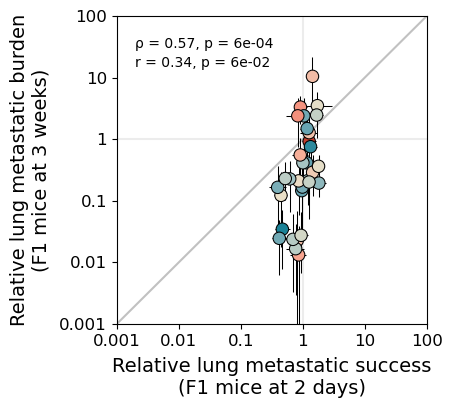

In [13]:
ax = utils.comparison_scatter_plot([x for x in clIDs if x not in ['GATC', 'AGCA']],
                                    clID__x=clID__in_vivo_exp_2d_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_2d_err,
                                    clID__y=clID__in_vivo_exp_avg_relative_to_mean, clID__yerr=clID__in_vivo_exp_err,
                                    xtitle='Relative lung metastatic success\n(F1 mice at 2 days)', ytitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)',
                                    lims=[1e-3, 1e2], ticks=[1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], labels=['0.001', '0.01', '0.1', '1', '10', '100'])

#plt.savefig(path_to_save_figs + 'fig3_success_vs_burden_f1.pdf', dpi=300, bbox_inches='tight')  

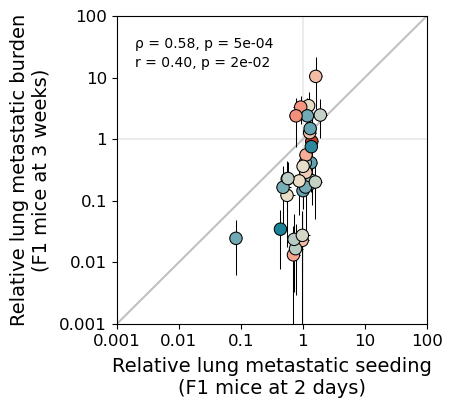

In [14]:
ax = utils.comparison_scatter_plot([x for x in clIDs if x not in ['GATC', 'AGCA']],
                                    clID__x=clID__n_tumors_avg_relative_to_mean, clID__xerr=clID__n_tumors_err,
                                    clID__y=clID__in_vivo_exp_avg_relative_to_mean, clID__yerr=clID__in_vivo_exp_err,
                                    xtitle='Relative lung metastatic seeding\n(F1 mice at 2 days)', ytitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)',
                                    lims=[1e-3, 1e2], ticks=[1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2], labels=['0.001', '0.01', '0.1', '1', '10', '100'])

#plt.savefig(path_to_save_figs + 'fig3_seeding_vs_burden_f1.pdf', dpi=300, bbox_inches='tight')  

In [15]:
# making a list of 2d Rag1 iv lung samples from exp. one
what = ['1', 3, 'Rag1-/-', 'intravenous', 'lung']
samples_wo_immune_system = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                                 (metadata['time point, d'] <= what[1]) & # be careful here
                                                 (metadata['genotype'] == what[2]) &
                                                 (metadata['injection method'] == what[3]) & 
                                                 (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [16]:
clID___distr_wo_immune_system, clID__n_tumors_avg_relative_to_mean_wo_immune_system, clID__n_tumors_err_wo_immune_system, clIDs_sorted_wo_immune_system = utils.bootstrap_n_tumors(samples_wo_immune_system, path_to_data=path_to_reads, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)


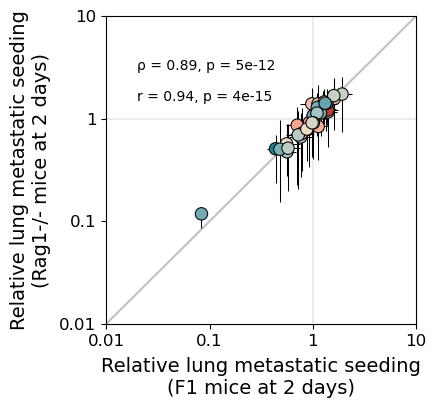

In [17]:
ax = utils.comparison_scatter_plot([x for x in clIDs if x not in ['GATC', 'AGCA']],
                                    clID__x=clID__n_tumors_avg_relative_to_mean, clID__xerr=clID__n_tumors_err,
                                    clID__y=clID__n_tumors_avg_relative_to_mean_wo_immune_system, clID__yerr=clID__n_tumors_err_wo_immune_system,
                                    xtitle='Relative lung metastatic seeding\n(F1 mice at 2 days)', ytitle='Relative lung metastatic seeding\n(Rag1-/- mice at 2 days)',
                                    lims=[0.01, 10], ticks=[1e-2, 1e-1, 1e0, 1e1], labels=['0.01', '0.1', '1', '10'])

#plt.savefig(path_to_save_figs + 'fig3_seeding_f1_vs_rag1.pdf', dpi=300, bbox_inches='tight')  

### Tumor size distributions

In [395]:
# making a list of 3w F1 iv lung samples from exp. one
what = ['1', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

print(len(samples))

20


In [58]:
clID__percentiles, clID__ci = utils.bootstrap_tumor_size_percentiles(samples,
                                                                     path_to_data=path_to_reads,
                                                                     percentiles=[50, 60, 70, 80, 90, 99],
                                                                     read_counts=read_counts_by_cell_line,
                                                                     metadata=metadata)

In [59]:
_, _, _, clIDs_sorted = utils.bootstrap_relative_burden(samples, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)


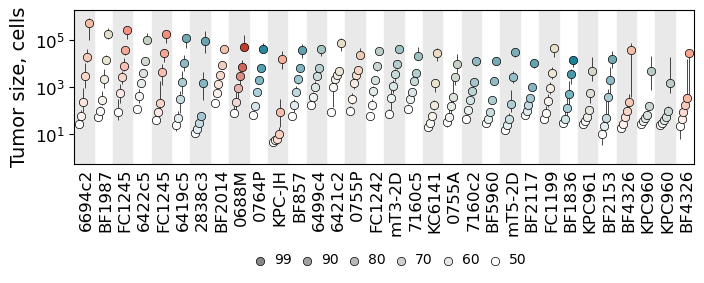

In [163]:
plt.figure(figsize=(8, 2))
for i, clID in enumerate(clIDs_sorted[:-1]):
    rgb = np.array(clID__color[clID])
    white = np.array([1, 1, 1, 1])
    gradient = np.linspace(white, rgb, len(clID__percentiles[clID]))
    for j, p in enumerate(clID__percentiles[clID]):
        plt.scatter(i + j * 0.1, clID__percentiles[clID][j], color=gradient[j], edgecolor='black', linewidth=0.5)
        plt.errorbar(i + j * 0.1, clID__percentiles[clID][j],  [[clID__percentiles[clID][j] - clID__ci[clID][0][j]], [clID__ci[clID][1][j] - clID__percentiles[clID][j]]], color='black', linewidth=0.5, zorder=-1)
    if i % 2 == 0:
        plt.fill_between([i - 0.25, i + j * 0.1 + 0.25], 5e-1, 2e6, color='#e9e9e9', zorder=-2)
        
# for legend:
gradient = np.linspace(np.array([1, 1, 1, 1]), np.array([0.537, 0.537, 0.537, 1]), len(clID__percentiles[clID]))[::-1]
for j, p in enumerate([50, 60, 70, 80, 90, 99][::-1]):
    plt.scatter(-1, clID__percentiles[clID][j], color=gradient[j], edgecolor='black', linewidth=0.5, label=p)
    
plt.yscale('log')
plt.minorticks_off()

plt.legend(frameon=False, bbox_to_anchor=(0.75, -0.5), ncol=len(gradient), handletextpad=0, columnspacing=0.1)

plt.ylim(5e-1, 2e6)
plt.xlim(-0.25, i + j * 0.1 + 0.25)
plt.yticks(size=12)

plt.xticks(range(0, len(clIDs_sorted[:-1])), [clID__label[clID] for clID in clIDs_sorted[:-1]], rotation=90, ha='left', size=12);
plt.gca().tick_params(axis='x', which='both', length=0)

plt.ylabel('Tumor size, cells', fontsize=14)

#plt.savefig(path_to_save_figs + 'fig3_tumor_size_distr.pdf', dpi=300, bbox_inches='tight')  

In [167]:
# want to plot cumulative burden distribution 
sample_clID_barcode__count = utils.convert_barcode_reads_to_cell_counts(samples, 
                                                                        path_to_data=path_to_reads, 
                                                                        read_counts=read_counts_by_cell_line, 
                                                                        metadata=metadata)
clID__tumor_sizes = {}
for i, clID in enumerate(clIDs[1:]):
    if clID not in clID__tumor_sizes:
        clID__tumor_sizes[clID] = []
    for sample in samples:
        clID__tumor_sizes[clID].extend([x for x in sample_clID_barcode__count[sample][clID].values()])


In [248]:
clID__sample__reads = {}
for sample in list(metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == '1')].index):
    clID__sample__reads[sample] = {}
    file_path = os.path.join(path_to_reads, f"{sample}_clIDs_rBC_cluster_counts.txt")
    
    with open(file_path, 'r') as f:
        for line in f:
            clID_barcode, read_count = line.strip().split('\t')
            clID, barcode = clID_barcode.split('_'); read_count = int(read_count)
            if clID not in clIDs: # this should not happen if barcodes were processed correctly
                continue
            if clID not in clID__sample__reads[sample]:
                clID__sample__reads[sample][clID] = []
            clID__sample__reads[sample][clID].append(read_count) # adding read counts!


Text(0, 0.5, 'Cumulative contribution to tumor burden')

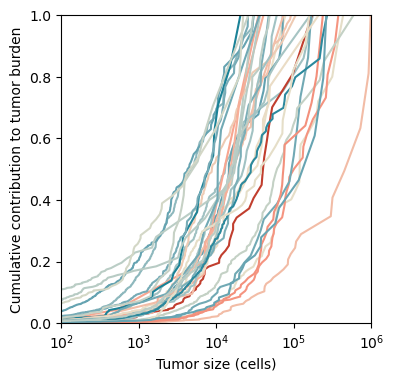

In [250]:
plt.figure(figsize=(4, 4))

for clID, tumor_sizes in clID__tumor_sizes.items():
    if clID in ['GATC', 'AGCA']:
        continue
    sorted_sizes = np.sort(tumor_sizes)

    cumulative_burden = np.cumsum(sorted_sizes)

    cumulative_burden /= cumulative_burden[-1]

    plt.plot(sorted_sizes, cumulative_burden, color=clID__color[clID], label=f"clID {clID}")
    
plt.xscale('log')
plt.minorticks_off()
plt.ylim(0, 1)
plt.xlim(1e2, 1e6)

plt.xlabel("Tumor size (cells)")
plt.ylabel("Cumulative contribution to tumor burden")

#plt.savefig(path_to_save_figs + 'fig3_cumulative_burden_by_size.pdf', dpi=300, bbox_inches='tight')  

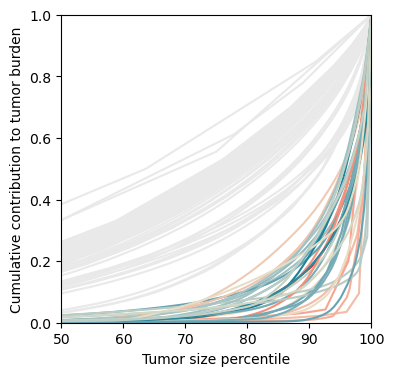

In [265]:
plt.figure(figsize=(4, 4))

# loop through each clID and plot cumulative burden vs percentile
for clID, tumor_sizes in clID__tumor_sizes.items():
    if clID in ['GATC', 'AGCA']:
            continue
    
    sorted_sizes = np.sort(tumor_sizes)
    cumulative_burden = np.cumsum(sorted_sizes) # cumulative burden
    cumulative_burden /= cumulative_burden[-1] # normalizing by the total burden

    # compute percentiles (rank of each size in sorted list)
    percentiles = np.linspace(0, 100, len(sorted_sizes))

    plt.plot(percentiles, cumulative_burden, color=clID__color[clID])
    
# now do the same but for pre-injection samples
for clID in clID__sample__reads.keys():
    if clID in ['GATC', 'AGCA']:
        continue
        
    for sample in clID__sample__reads[clID].keys():
        tumor_sizes = clID__sample__reads[clID][sample]
        sorted_sizes = np.sort(tumor_sizes)
        cumulative_burden = np.cumsum(sorted_sizes).astype(float)  # cumulative burden
        cumulative_burden /= cumulative_burden[-1] # normalizing by the total burden

        # compute percentiles (rank of each size in sorted list)
        percentiles = np.linspace(0, 100, len(sorted_sizes))

        plt.plot(percentiles, cumulative_burden, color='#e9e9e9', zorder=-1)
    
plt.xlim(50, 100)
plt.ylim(0, 1)

plt.xlabel("Tumor size percentile")
plt.ylabel("Cumulative contribution to tumor burden")

#plt.savefig(path_to_save_figs + 'fig3_cumulative_burden_by_rank.pdf', dpi=300, bbox_inches='tight')  

Text(0, 0.5, 'Relative Gini coefficient')

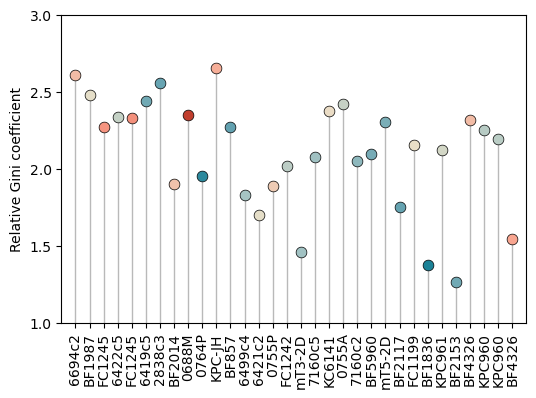

In [269]:
plt.figure(figsize=(6, 4))

def gini_coefficient(tumor_sizes):
    tumor_sizes = np.sort(tumor_sizes)  # sort sizes
    n = len(tumor_sizes)
    cumulative_sum = np.cumsum(tumor_sizes)
    return (2 * np.sum((np.arange(1, n + 1) * tumor_sizes)) - (n + 1) * cumulative_sum[-1]) / (n * cumulative_sum[-1])

for i, clID in enumerate(clIDs_sorted):
    if clID in ['GATC', 'AGCA']:
        continue
        
    comparison = np.mean([gini_coefficient(clID__sample__reads[sample][clID]) for sample in clID__sample__reads.keys()])    
    plt.scatter(i, gini_coefficient(clID__tumor_sizes[clID]) / comparison, color=clID__color[clID], s=60, edgecolor='black', linewidth=0.5)
    plt.plot([i, i], [1, gini_coefficient(clID__tumor_sizes[clID]) / comparison], color='#b9b9b9', linewidth=1, zorder=-1)
    
plt.ylim(1, 3)
plt.yticks([1, 1.5, 2, 2.5, 3])
plt.xticks(range(0, len(clIDs_sorted[:-1])), [clID__label[clID] for clID in clIDs_sorted[:-1]], 
           rotation=90, ha='center', size=10);
plt.xlim(-1, i)

plt.ylabel("Relative Gini coefficient")

#plt.savefig(path_to_save_figs + 'fig3_relative_gini_coefficient.pdf', dpi=300, bbox_inches='tight')  

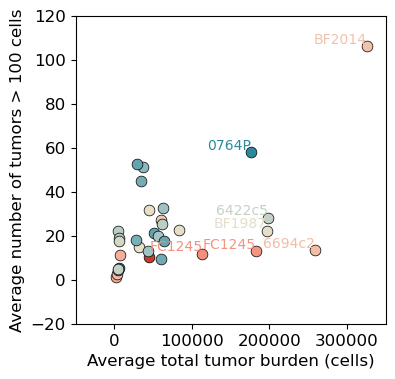

In [328]:
plt.figure(figsize=(4, 4))

for clID, tumor_sizes in clID__tumor_sizes.items():
    if clID in ['GATC', 'AGCA']:
        continue

    plt.scatter(np.sum(tumor_sizes) / len(samples), len(np.array(tumor_sizes) > 100) / len(samples), s=60, linewidth=0.5, color=clID__color[clID], edgecolor='black')
    
    if np.sum(tumor_sizes) / len(samples) > 1e5:
        plt.text(np.sum(tumor_sizes) / len(samples), len(np.array(tumor_sizes) > 100) / len(samples), clID__label[clID], va='bottom', ha='right', color=clID__color[clID])
    
plt.xlabel('Average total tumor burden (cells)', size=12)
plt.ylabel('Average number of tumors > 100 cells', size=12)

plt.xticks(size=12); plt.yticks(size=12);

plt.xlim(-50000, 350000)
plt.ylim(-20, 120)

#plt.savefig(path_to_save_figs + 'fig3_n_tumors_vs_burden.pdf', dpi=300, bbox_inches='tight')  

In [347]:
# slightly different from above as we are keeping the barcodes now
clID__sample__reads = {}
for sample in list(metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == '1')].index):
    clID__sample__reads[sample] = {}
    file_path = os.path.join(path_to_reads, f"{sample}_clIDs_rBC_cluster_counts.txt")
    
    with open(file_path, 'r') as f:
        for line in f:
            clID_barcode, read_count = line.strip().split('\t')
            clID, barcode = clID_barcode.split('_'); read_count = int(read_count)
            if clID not in clIDs: # this should not happen if barcodes were processed correctly
                continue
            if clID not in clID__sample__reads[sample]:
                clID__sample__reads[sample][clID] = {}
            clID__sample__reads[sample][clID][barcode] = read_count # adding read counts!
            
sample_clID_barcode__count = utils.convert_barcode_reads_to_cell_counts(samples, 
                                                                        path_to_data=path_to_reads, 
                                                                        read_counts=read_counts_by_cell_line, 
                                                                        metadata=metadata)
clID__sample__freqs = {}
for sample in list(metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == '1')].index):
    n_total = sum([sum(clID__sample__reads[sample][i].values()) for i in clIDs if i not in ['GATC', 'AGCA']])
    
    clID__sample__freqs[sample] = {}
    for clID, barcodes in clID__sample__reads[sample].items():
        if clID in ['GATC', 'AGCA']:
            continue 
        clID__sample__freqs[sample][clID] = {} 

        for barcode, count in barcodes.items():
            clID__sample__freqs[sample][clID][barcode] = count / n_total 

clID__barcodes = {}
for i, clID in enumerate(clIDs[1:]):
    if clID not in clID__barcodes:
        clID__barcodes[clID] = []
    for sample in samples:
        clID__barcodes[clID].extend([x for x in sample_clID_barcode__count[sample][clID].keys()])
        

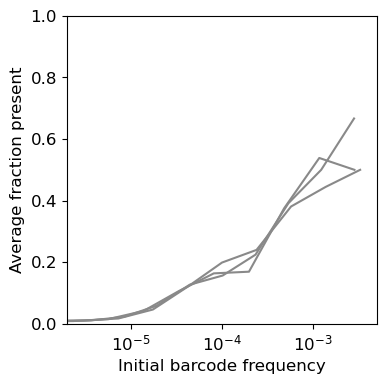

In [394]:
plt.figure(figsize=(4, 4))
for sample in list(metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == '1')].index):
    f_presence = []
    for clID in clIDs:
        if clID in ['GATC', 'AGCA']:
            continue
        for barcode, f in clID__sample__freqs[sample][clID].items():
            f_presence.append([f, 1 if barcode in clID__barcodes[clID] else 0])

    f_presence = np.array(f_presence)
    frequencies = f_presence[:, 0]  
    presences = f_presence[:, 1]    
    
    n_bins = 100
    bins = np.logspace(np.log10(min(frequencies)), np.log10(max(frequencies)), num_bins + 1)
    bin_indices = np.digitize(frequencies, bins) - 1  

    avg_presence = []
    bin_centers = []

    for i in range(num_bins):
        bin_mask = bin_indices == i  # get indices of frequencies in this bin
        bin_count = np.sum(bin_mask)  # total number of data points in the bin

        avg_presence.append(np.mean(presences[bin_mask]))  # compute fraction present
        bin_centers.append(np.sqrt(bins[i] * bins[i+1]))  # use geometric mean as bin center

    plt.plot(bin_centers, avg_presence, color='#898989')

    plt.xscale('log')
    plt.minorticks_off()
    plt.ylim(0, 1)
    plt.xlim(2e-6, 5e-3)
    plt.xticks(size=12)
    plt.yticks(size=12)
    plt.xlabel('Initial barcode frequency', size=12)
    plt.ylabel('Average fraction present', size=12)
    
#plt.savefig(path_to_save_figs + 'fig3_fraction_present_vs_freq.pdf', dpi=300, bbox_inches='tight')  